University of Surrey
Emotion aware music recommender system with Explainable AI

Name: Minal Honali Raghunandan

Student ID: 6908107

### Multimodal Emotion Recognition Feasibility Study


This notebook investigates the integration of textual lyric representations with low-level acoustic descriptors to assess multimodal regression performance on continuous Valence–Arousal coordinates. Using LRCLIB for lyric retrieval and all-MiniLM-L6-v2 for dense semantic text embeddings, this experiment benchmarks Audio-only, Lyrics-only, and Early-Fusion multimodal representations across the DEAM corpus under cross-validation.

#### Environment Setup & Dependency Installation

Installs required packages for dense transformer embeddings and sets up persistent storage on Google Drive. Imports core scientific computing, machine learning, and visualization libraries.

In [ ]:
!pip install -q lyricsgenius sentence-transformers

import os
import re
import time
from google.colab import drive
import lyricsgenius
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive
drive.mount('/content/drive')

# Paths & Metadata Load
DATA_PATH = '/content/drive/MyDrive/Dissertation/data/processed'
df_pool = pd.read_csv(os.path.join(DATA_PATH, 'song_pool_predictions.csv'))

# Verify column presence
print(f'Columns in song_pool_predictions: {list(df_pool.columns)}')
print(f'Total songs available: {len(df_pool)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Columns in song_pool_predictions: ['song_id', 'pred_valence', 'pred_arousal', 'Artist', 'title', 'Genre']
Total songs available: 1744


Load predicted Valence-Arousal coordinates and DEAM track metadata from the processed repository.

In [ ]:
df_pool['song_id'] = df_pool['song_id'].astype(int)


GENIUS_TOKEN = '0otJGXQYmv8sDck2sKWE_wXGJpXY4Jkeb7qFooo5o9SYre7RzsR0LrwEhdTLCoif'

lyric_genie = lyricsgenius.Genius(
    GENIUS_TOKEN,
    timeout=15,
    retries=2,
    sleep_time=0.5,
    remove_section_headers=True,
)
lyric_genie.verbose = False

Iterate over unretrieved catalogue tracks using exact title-artist endpoint queries with fallback keyword search on the LRCLIB open registry. Sanitize brackets and track numbers, filtering retrieved bodies under a 30-character length threshold.

In [ ]:
#output storage in gdrive
LYRICS_PATH = os.path.join(DATA_PATH, 'deam_lyrics_scraped.csv')

if os.path.exists(LYRICS_PATH):
  df_lyrics_path = pd.read_csv(LYRICS_PATH)
  df_lyrics_path['song_id'] = df_lyrics_path['song_id'].astype(int)
  scraped_ids = set(df_lyrics_path['song_id'].tolist())
  print(
      f'Found existing save file. Already processed: {len(scraped_ids)} tracks'
  )
else:
  df_lyrics_path = pd.DataFrame(
      columns=['song_id', 'Artist', 'title', 'lyrics', 'status']
  )
  scraped_ids = set()

Found existing save file. Already processed: 100 tracks


In [ ]:
# sanitize search terms from DEAM metadata
def clean_metadata_text(text):
  if not isinstance(text, str):
    return ''
  # Strip genre/id tags in brackets or parenthesis
  text = re.sub(r'\(.*?\)|\[.*?\]', '', text)
  # Strip track number prefixes
  text = re.sub(r'^\d+\s*[-_]\s*', '', text)
  return text.strip()

In [ ]:
# clean and normalise Genius lyrics body
def clean_genius_lyrics(raw_lyrics):
  if not isinstance(raw_lyrics, str):
    return ''
  clean = re.sub(r'^.*?Lyrics', '', raw_lyrics, flags=re.DOTALL)
  clean = re.sub(r'\d*Embed$', '', clean)
  clean = re.sub(r'You might also like', '', clean)
  # Normalize excessive newlines
  clean = re.sub(r'\n+', '\n', clean)
  return clean.strip()

Generates 384-dimensional dense semantic text embeddings for all matched lyric bodies using the pretrained `all-MiniLM-L6-v2` transformer model. Constructs the unified multimodal early-fusion matrix by concatenating acoustic and textual vectors.

In [ ]:
import requests
unscraped = df_pool[~df_pool['song_id'].isin(scraped_ids)].copy()

BATCH_SIZE = 100
to_process = unscraped.head(BATCH_SIZE)

print(f'Starting LRCLIB query for {len(to_process)} tracks...')

res = df_lyrics_path.to_dict('records')
headers = {
    'User-Agent': (
        'MSc-MusicEmotionResearch/1.0 (https://github.com/Minalhr55)'
    )  #[cite: 2]
}

for count, (_, row) in enumerate(to_process.iterrows(), start=1):
  s_id = int(row['song_id'])
  artist_raw = str(row['Artist']) if pd.notna(row['Artist']) else ''
  title_raw = str(row['title']) if pd.notna(row['title']) else ''

  clean_title = clean_metadata_text(title_raw)
  clean_artist = clean_metadata_text(artist_raw)

  search_title = clean_title if len(clean_title) > 0 else title_raw
  search_artist = clean_artist if len(clean_artist) > 0 else artist_raw

  record = {
      'song_id': s_id,
      'Artist': artist_raw,
      'title': title_raw,
      'lyrics': '',
      'status': 'not_found',
  }

  try:
    url_get = 'https://lrclib.net/api/get'
    params_get = {'track_name': search_title, 'artist_name': search_artist}
    res_get = requests.get(
        url_get, params=params_get, headers=headers, timeout=10
    )

    lyrics_text = ''
    if res_get.status_code == 200:
      data = res_get.json()
      lyrics_text = data.get('plainLyrics') or data.get('syncedLyrics') or ''

    if not lyrics_text:
      url_search = 'https://lrclib.net/api/search'
      params_search = {'q': f'{search_artist} {search_title}'}
      res_search = requests.get(
          url_search, params=params_search, headers=headers, timeout=10
      )
      if res_search.status_code == 200:
        search_hits = res_search.json()
        if search_hits and len(search_hits) > 0:
          first_hit = search_hits[0]
          lyrics_text = (
              first_hit.get('plainLyrics')
              or first_hit.get('syncedLyrics')
              or ''
          )

    cleaned_lyrics = clean_genius_lyrics(lyrics_text)

    if len(cleaned_lyrics) > 30:
      record['lyrics'] = cleaned_lyrics
      record['status'] = 'found'
      print(
          f'[{count}/{len(to_process)}] FOUND: {s_id} | {search_artist} -'
          f' {search_title}'
      )
    else:
      print(
          f'[{count}/{len(to_process)}] NOT FOUND: {s_id} | {search_artist} -'
          f' {search_title}'
      )

  except Exception as e:
    record['status'] = f'error: {str(e)[:40]}'
    print(f'[{count}/{len(to_process)}] ERROR on {s_id}: {e}')

  res.append(record)
  time.sleep(0.3)

  # Checkpoint to Drive every 20 tracks
  if count % 20 == 0 or count == len(to_process):
    df_checkpoint = pd.DataFrame(res)
    df_checkpoint.to_csv(LYRICS_PATH, index=False)
    print(f'--> Saved checkpoint: {len(df_checkpoint)} records in Drive.')

# Final summary
df_final = pd.DataFrame(res)
found_total = len(df_final[df_final['status'] == 'found'])
total_processed = len(df_final)

print('\n=== SCRAPING SUMMARY ===')
print(f'Total processed: {total_processed}')
print(
    f'Lyrics found: {found_total} ({round((found_total/total_processed)*100, 2)}%'
    ' recovery rate)'
)

Starting LRCLIB query for 100 tracks...
[1/100] NOT FOUND: 126 | Lee Maddeford - Le petit jardin
[2/100] NOT FOUND: 127 | Evgeny Grinko - Sunset
[3/100] NOT FOUND: 128 | Fabrizio Paterlini - Veloma
[4/100] NOT FOUND: 129 | Oskar Schuster - Sneeuwland
[5/100] NOT FOUND: 130 | Jared C. Balogh - Strides
[6/100] NOT FOUND: 131 | Dexter Britain - Wonderland
[7/100] NOT FOUND: 133 | Ophir Ilzetzki - Aleph
[8/100] NOT FOUND: 134 | Dexter Britain - Summers Coming
[9/100] NOT FOUND: 135 | Jody Pou - O Solitude (H
[10/100] NOT FOUND: 136 | Mystic Morrison Visions - Fourth
[11/100] NOT FOUND: 137 | Aaron Dunn-Sonatina No. 1 in C Major - I
[12/100] NOT FOUND: 138 | Silver Process - Encounters With Abusive Men
[13/100] NOT FOUND: 140 | Jared C. Balogh - Shaking Off The Rust
[14/100] NOT FOUND: 142 | Circus Marcus-Aux puces nº2 - Carosello
[15/100] NOT FOUND: 143 | Circus Marcus - Aux puces nº5
[16/100] NOT FOUND: 144 | krackatoa - The Passing of Time
[17/100] NOT FOUND: 145 | Kevin MacLeod - The Fo

In [ ]:
# load data
X_train = pd.read_csv(os.path.join(DATA_PATH, "X_train.csv"))
y_train = pd.read_csv(os.path.join(DATA_PATH, "y_train.csv"))
X_test = pd.read_csv(os.path.join(DATA_PATH, "X_test.csv"))
y_test = pd.read_csv(os.path.join(DATA_PATH, "y_test.csv"))

In [ ]:
# sanitise col names
regx = re.compile(r"\[\]|<", re.IGNORECASE)
X_train.columns = [regx.sub("_", col) if isinstance(col, str) else col for col in X_train.columns]
X_test.columns = [regx.sub("_", col) if isinstance(col, str) else col for col in X_test.columns]

# Combine into complete acoustic dataset
X_audio_full = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

In [ ]:
# Load Scraped Lyrics and Filter for Valid Text
df_all_lyrics = pd.read_csv(os.path.join(DATA_PATH, "deam_lyrics_scraped.csv"))
df_valid_lyrics = df_all_lyrics[df_all_lyrics['status'] == 'found'].copy().reset_index(drop=True)

print(f"Total matched songs with lyrics: {len(df_valid_lyrics)}")

Total matched songs with lyrics: 12


In [ ]:
# Extract Text Embeddings with MiniLM
device = "cuda" if torch.cuda.is_available() else "cpu"
embedder = SentenceTransformer('all-MiniLM-L6-v2', device=device)

lyrics_list = df_valid_lyrics['lyrics'].tolist()
print(f"Generating 384-d semantic text embeddings for {len(lyrics_list)} songs on {device}...")
text_embeddings = embedder.encode(lyrics_list, show_progress_bar=True, batch_size=16)

df_text_emb = pd.DataFrame(
    text_embeddings,
    columns=[f"lyric_emb_{i}" for i in range(text_embeddings.shape[1])]
)
df_text_emb['song_id'] = df_valid_lyrics['song_id'].astype(int)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Generating 384-d semantic text embeddings for 12 songs on cpu...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Align Audio and Lyrics Datasets by song_id
df_pool = pd.read_csv(os.path.join(DATA_PATH, "song_pool_predictions.csv"))
df_pool['song_id'] = df_pool['song_id'].astype(int)

if 'song_id' not in X_audio_full.columns:
    X_audio_full['song_id'] = df_pool['song_id'].iloc[:len(X_audio_full)].values

if 'song_id' not in y_full.columns:
    y_full['song_id'] = df_pool['song_id'].iloc[:len(y_full)].values

merged_subset = pd.merge(df_valid_lyrics[['song_id']], X_audio_full, on='song_id', how='inner')
merged_subset = pd.merge(merged_subset, df_text_emb, on='song_id', how='inner')
merged_subset = pd.merge(merged_subset, y_full, on='song_id', how='inner')

# Separate feature matrices for the matched subset
audio_cols = [c for c in X_audio_full.columns if c != 'song_id']
text_cols = [c for c in df_text_emb.columns if c != 'song_id']
target_cols = [c for c in y_full.columns if c != 'song_id']

X_audio_sub = merged_subset[audio_cols].values
X_text_sub = merged_subset[text_cols].values
X_multi_sub = np.hstack([X_audio_sub, X_text_sub])

y_val_sub = merged_subset[target_cols[0]].values  # Valence
y_aro_sub = merged_subset[target_cols[1]].values  # Arousal

print(f"Matched subset evaluation matrix shape: {X_multi_sub.shape}")

Matched subset evaluation matrix shape: (12, 686)


In [ ]:
# Benchmarking Evaluation Across Modalities
k_splits = 5 if len(merged_subset) >= 20 else 3
kf_sub = KFold(n_splits=k_splits, shuffle=True, random_state=42)

def evaluate_modality_cv(X_mat, y_vec, modality_name, target_name):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_mat)

    model = Ridge(alpha=10.0, random_state=42)
    scores = cross_validate(
        model, X_scaled, y_vec, cv=kf_sub,
        scoring={'r2': 'r2', 'neg_rmse': 'neg_root_mean_squared_error', 'neg_mae': 'neg_mean_absolute_error'}
    )
    return {
        'Modality': modality_name,
        'Target': target_name,
        'R2': round(float(np.mean(scores['test_r2'])), 4),
        'RMSE': round(float(-np.mean(scores['test_neg_rmse'])), 4),
        'MAE': round(float(-np.mean(scores['test_neg_mae'])), 4)
    }

modalities = {
    'Audio Only (openSMILE)': X_audio_sub,
    'Lyrics Only (MiniLM)': X_text_sub,
    'Multimodal (Early Fusion)': X_multi_sub
}

targets_dict = {'Valence': y_val_sub, 'Arousal': y_aro_sub}
cv_results = []

for mod_name, X_m in modalities.items():
    for targ_name, y_t in targets_dict.items():
        res = evaluate_modality_cv(X_m, y_t, mod_name, targ_name)
        cv_results.append(res)

df_multimodal_res = pd.DataFrame(cv_results)
print("\n=== MULTIMODAL FEASIBILITY BENCHMARK ===")
print(df_multimodal_res.pivot(index='Modality', columns='Target'))


=== MULTIMODAL FEASIBILITY BENCHMARK ===
                               R2            RMSE             MAE        
Target                    Arousal Valence Arousal Valence Arousal Valence
Modality                                                                 
Audio Only (openSMILE)     0.3750 -0.4327  0.2937  0.3134  0.2331  0.2746
Lyrics Only (MiniLM)       0.1969 -0.0076  0.3488  0.2776  0.3032  0.2472
Multimodal (Early Fusion)  0.5201 -0.0662  0.2718  0.2788  0.2494  0.2417


In [ ]:
# enchmarking Evaluation Across Modalities
k_splits = 5 if len(merged_subset) >= 20 else 3
kf = KFold(n_splits=k_splits, shuffle=True, random_state=42)

def evaluate_modality_cv(X_mat, y_vec, modality_name, target_name):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_mat)

    model = Ridge(alpha=10.0, random_state=42)
    scores = cross_validate(
        model, X_scaled, y_vec, cv=kf,
        scoring={'r2': 'r2', 'neg_rmse': 'neg_root_mean_squared_error', 'neg_mae': 'neg_mean_absolute_error'}
    )
    return {
        'Modality': modality_name,
        'Target': target_name,
        'R2': round(float(np.mean(scores['test_r2'])), 4),
        'RMSE': round(float(-np.mean(scores['test_neg_rmse'])), 4),
        'MAE': round(float(-np.mean(scores['test_neg_mae'])), 4)
    }

modalities = {
    'Audio Only (openSMILE)': X_audio_sub,
    'Lyrics Only (MiniLM)': X_text_sub,
    'Multimodal (Early Fusion)': X_multi_sub
}

targets_dict = {'Valence': y_val_sub, 'Arousal': y_aro_sub}
cv_results = []

for mod_name, X_m in modalities.items():
    for targ_name, y_t in targets_dict.items():
        res = evaluate_modality_cv(X_m, y_t, mod_name, targ_name)
        cv_results.append(res)

df_multimodal_res = pd.DataFrame(cv_results)
print("\n=== MULTIMODAL FEASIBILITY BENCHMARK ===")
print(df_multimodal_res.pivot(index='Modality', columns='Target'))


=== MULTIMODAL FEASIBILITY BENCHMARK ===
                               R2            RMSE             MAE        
Target                    Arousal Valence Arousal Valence Arousal Valence
Modality                                                                 
Audio Only (openSMILE)     0.3750 -0.4327  0.2937  0.3134  0.2331  0.2746
Lyrics Only (MiniLM)       0.1969 -0.0076  0.3488  0.2776  0.3032  0.2472
Multimodal (Early Fusion)  0.5201 -0.0662  0.2718  0.2788  0.2494  0.2417


Plot saved to: /content/drive/MyDrive/Dissertation/data/processed/multimodal_feasibility_benchmark.png


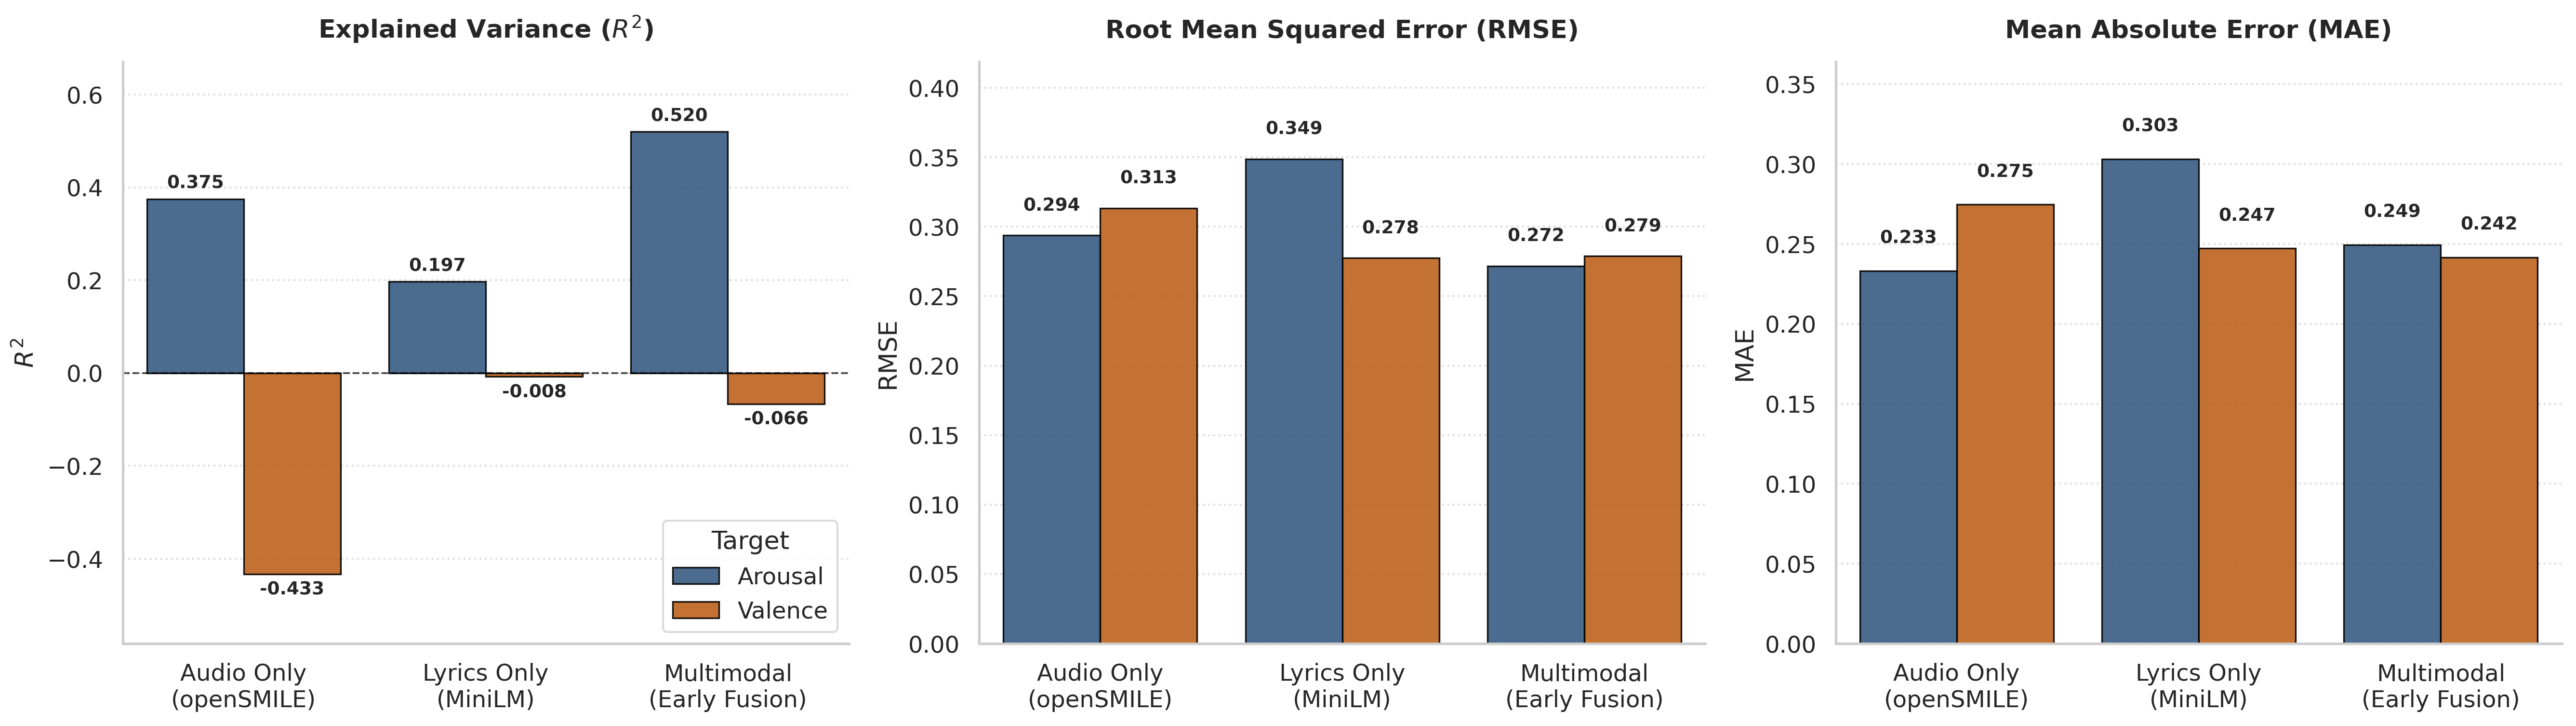

In [ ]:


sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

metrics = ["R2", "RMSE", "MAE"]
metric_titles = [
    r"Explained Variance ($R^2$)",
    "Root Mean Squared Error (RMSE)",
    "Mean Absolute Error (MAE)",
]

label_map = {
    "Audio Only (openSMILE)": "Audio Only\n(openSMILE)",
    "Lyrics Only (MiniLM)": "Lyrics Only\n(MiniLM)",
    "Multimodal (Early Fusion)": "Multimodal\n(Early Fusion)",
}

df_vis = df_multimodal_res.copy()
df_vis["Modality"] = df_vis["Modality"].map(label_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), dpi=300)

palette = {"Arousal": "#2b5c8f", "Valence": "#d95f02"}
modalities_order = list(label_map.values())
target_order = ["Arousal", "Valence"]  # Enforces identical bar ordering across all plots

for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
  ax = axes[idx]

  sns.barplot(
      data=df_vis,
      x="Modality",
      y=metric,
      hue="Target",
      order=modalities_order,
      hue_order=target_order,
      palette=palette,
      ax=ax,
      edgecolor="black",
      linewidth=0.8,
      alpha=0.9,
  )

  ax.set_title(title, fontweight="bold", pad=12)
  ax.set_xlabel("")
  ax.set_ylabel(metric if metric != "R2" else r"$R^2$")
  ax.grid(axis="y", linestyle=":", alpha=0.6)
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)

  if metric == "R2":
    ax.axhline(0, color="black", linestyle="--", linewidth=0.9, alpha=0.7)
    min_val = df_vis[metric].min()
    max_val = df_vis[metric].max()
    ax.set_ylim(min_val - 0.15, max_val + 0.15)
  else:
    max_val = df_vis[metric].max()
    ax.set_ylim(0, max_val * 1.2)

  for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height != 0:
      if height >= 0:
        va_align = "bottom"
        y_pos = height + 0.015
      else:
        va_align = "top"
        y_pos = height - 0.015

      ax.annotate(
          f"{height:.3f}",
          (p.get_x() + p.get_width() / 2.0, y_pos),
          ha="center",
          va=va_align,
          fontsize=9,
          fontweight="semibold",
      )

  if idx == 0:
    ax.legend(
        title="Target", frameon=True, facecolor="white", edgecolor="lightgray"
    )
  else:
    ax.get_legend().remove()

plt.tight_layout()

SAVE_PLOT_PATH = os.path.join(
    DATA_PATH, "multimodal_feasibility_benchmark.png"
)
plt.savefig(SAVE_PLOT_PATH, dpi=300, bbox_inches="tight")
print(f"Plot saved to: {SAVE_PLOT_PATH}")
plt.show()